# TP — KNN: Clasificación de Riesgo Crediticio

## Objetivo

En este trabajo vamos a construir **juntos, paso a paso**, un modelo de **K-Nearest Neighbors (KNN)** para clasificar clientes según su riesgo crediticio.

Al finalizar deberías poder:

- reconocer un problema de clasificación;
- separar variables predictoras y variable objetivo;
- dividir los datos en entrenamiento y prueba;
- comprender por qué KNN necesita escalado;
- aplicar `StandardScaler`;
- elegir el mejor valor de `k` mediante validación cruzada;
- evaluar el modelo con Accuracy, Precision, Recall, F1, matriz de confusión y ROC-AUC;
- realizar una predicción para un nuevo cliente.


# Repaso K-Vecinos Más Cercanos (KNN)

En este cuaderno vamos a conocer otro algoritmo de **Aprendizaje Supervisado**: el de **K-Vecinos Más Cercanos**, también conocido por su nombre en inglés, *K-Nearest Neighbors* (**KNN**).

KNN se puede usar tanto para *clasificación* (predecir una categoría) como para *regresión* (predecir un número), y en este cuaderno lo vamos a usar para clasificación.

La idea detrás de KNN es muy simple y se parece a algo que probablemente ya hacés de forma intuitiva: para clasificar un nuevo dato, buscamos los 'k' datos más parecidos que ya conocemos (sus 'vecinos') y lo asignamos a la clase que es más frecuente entre esos vecinos.

KNN **no aprende ninguna regla**: durante el entrenamiento simplemente *memoriza* todos los datos, y recién decide en el momento en que le pedimos una predicción. Por eso se lo conoce como un modelo "**perezoso**" (*lazy learning*).

### ¿Cómo funciona KNN, paso a paso?

Antes de entrar en código, veamos los cuatro pasos que sigue KNN cada vez que tiene que predecir:

1. **Elegir k**: cuántos vecinos se van a considerar.
2. **Calcular distancias**: medir qué tan lejos está el cliente nuevo de cada cliente que ya conocemos.
3. **Seleccionar vecinos**: quedarse con los k clientes más cercanos.
4. **Votar la clase**: asignar al cliente nuevo la clase (Alto/Bajo) más frecuente entre esos k vecinos.

## ¿Qué significa "cercano"? Métricas de distancia

Para decidir quiénes son los vecinos más parecidos, KNN necesita una fórmula de distancia entre dos clientes, pensados como puntos en un espacio donde cada variable (edad, ingreso, etc.) es una dimensión. Las más comunes son:

- **Distancia Euclidiana** (la que usa KNN por defecto): la línea recta entre dos puntos.
$$d(x,y) = \sqrt{\sum_i (x_i - y_i)^2}$$

- **Distancia Manhattan**: suma las diferencias absolutas de cada variable, como moverse en cuadras de una ciudad en lugar de en línea recta.
$$d(x,y) = \sum_i |x_i - y_i|$$

- **Distancia Minkowski**: generaliza a las dos anteriores con un parámetro `p`. Con `p=2` es la Euclidiana, con `p=1` es la Manhattan (`sklearn` usa Minkowski con `p=2` por defecto, que es lo mismo que Euclidiana).

## Antes de programar: pensemos el problema

El banco quiere predecir si un cliente tiene:

- **Alto** riesgo crediticio
- **Bajo** riesgo crediticio

### Preguntas que deberiamos hacernos

1. ¿Cuál es la variable objetivo?
2. ¿Es un problema de clasificación o regresión?
3. ¿Qué tipo de variables utilizaremos como predictoras?
4. ¿Por qué KNN necesita una medida de distancia?


## 1. Importación de librerías

Completá las importaciones necesarias para:

- Pandas
- NumPy
- Matplotlib
- `train_test_split`
- `StandardScaler`
- `KNeighborsClassifier`
- `GridSearchCV`
- las métricas que utilizaremos para evaluar el modelo.


In [1]:
# Completar las importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


## 2. Cargar el dataset

El dataset contiene información de clientes como edad, ingresos, antigüedad laboral, créditos, historial de pagos y deuda.

Cargá el archivo y observá las primeras filas.


In [2]:
# Cargar el dataset
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1gvojBZ8BzYzWV_h6SJBYs6d5_A6_jWhV")
df.head()


,ClienteID,Edad,IngresoMensualUSD,AntiguedadLaboralAnios,CreditosActivos,HistorialPagosPct,DeudaActualUSD,GastoMensualEstimadoUSD,RiesgoCrediticio,SolicitudTarjeta
0,C0001,59,4521,26,0,74,1275,1645,Bajo,Aprobada
1,C0002,49,4519,4,2,68,1964,1238,Bajo,Rechazada
2,C0003,35,4521,19,2,56,1299,1578,Bajo,Rechazada
3,C0004,63,9194,10,0,63,2551,2418,Bajo,Rechazada
4,C0005,28,4599,9,4,91,1924,1542,Bajo,Aprobada


## 3. Exploración inicial

Antes de entrenar un modelo debemos conocer los datos.

Ejecutá:

- `df.info()`
- `df.describe()`

### Preguntas

- ¿Cuántas filas tiene el dataset?
- ¿Cuántas variables numéricas hay?
- ¿Hay valores nulos?
- ¿Qué variable representa la clase que queremos predecir?

### Respuestas

- El dataset tiene **400 filas** (clientes).
- Hay **7 variables numéricas** (`Edad`, `IngresoMensualUSD`, `AntiguedadLaboralAnios`, `CreditosActivos`, `HistorialPagosPct`, `DeudaActualUSD`, `GastoMensualEstimadoUSD`), más `ClienteID`, `RiesgoCrediticio` y `SolicitudTarjeta`, que son categóricas/texto.
- **No hay valores nulos** en ninguna columna (`df.info()` muestra 400 valores no nulos en todas).
- La variable objetivo (la clase a predecir) es **`RiesgoCrediticio`**, con valores `Alto` / `Bajo`.


In [3]:
# Exploración inicial
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ClienteID                400 non-null    str  
 1   Edad                     400 non-null    int64
 2   IngresoMensualUSD        400 non-null    int64
 3   AntiguedadLaboralAnios   400 non-null    int64
 4   CreditosActivos          400 non-null    int64
 5   HistorialPagosPct        400 non-null    int64
 6   DeudaActualUSD           400 non-null    int64
 7   GastoMensualEstimadoUSD  400 non-null    int64
 8   RiesgoCrediticio         400 non-null    str  
 9   SolicitudTarjeta         400 non-null    str  
dtypes: int64(7), str(3)
memory usage: 31.4 KB


In [4]:
df.describe()


,Edad,IngresoMensualUSD,AntiguedadLaboralAnios,CreditosActivos,HistorialPagosPct,DeudaActualUSD,GastoMensualEstimadoUSD
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.00000
mean,45.752500,3819.765000,17.902500,2.552500,77.030000,2077.30000,1270.00000
std,14.198424,1376.483597,10.292367,1.695414,13.492748,910.57491,453.26163
min,21.000000,900.000000,0.000000,0.000000,55.000000,0.00000,150.00000
25%,34.000000,2867.000000,9.000000,1.000000,65.000000,1367.75000,951.25000
50%,47.000000,3822.000000,18.000000,3.000000,77.000000,2076.50000,1294.00000
75%,57.000000,4706.000000,27.000000,4.000000,89.000000,2732.25000,1554.00000
max,69.000000,9194.000000,35.000000,5.000000,100.000000,4983.00000,2826.00000


## 4. Distribución de la variable objetivo

Visualizá la cantidad de clientes de cada clase de `RiesgoCrediticio`.

### Pregunta

¿Las clases están aproximadamente equilibradas o existe una diferencia importante entre ellas?

### Respuesta

Las clases están **muy desbalanceadas**: 371 clientes son de riesgo `Bajo` y solo 29 son de riesgo `Alto` (≈93 % vs ≈7 %). Esto es importante porque un modelo que prediga siempre "Bajo" tendría un Accuracy alto (~93 %) sin ser útil: hay que mirar métricas como Recall y Precision de la clase minoritaria (`Alto`), no solo el Accuracy.


RiesgoCrediticio
Bajo    371
Alto     29
Name: count, dtype: int64


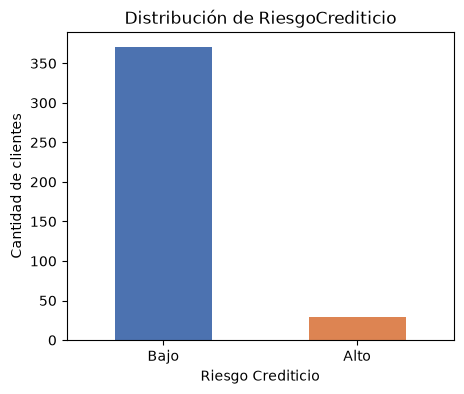

In [5]:
# Distribución de la variable objetivo
conteo = df['RiesgoCrediticio'].value_counts()
print(conteo)

plt.figure(figsize=(5, 4))
conteo.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Distribución de RiesgoCrediticio')
plt.xlabel('Riesgo Crediticio')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.show()


## 5. Analizando correlaciones

Calculá la matriz de correlación de las variables numéricas.

### Pregunta

¿Encontrás alguna relación relativamente fuerte entre variables?

Recordá: una correlación alta entre dos variables predictoras puede indicar **redundancia**, pero no significa causalidad.

### Respuesta

Sí: `GastoMensualEstimadoUSD` correlaciona fuertemente con `IngresoMensualUSD` (≈0.81) y, en menor medida, con `AntiguedadLaboralAnios` (≈0.42). Esa es justamente la razón por la que en el punto 6 se excluye `GastoMensualEstimadoUSD` de las predictoras: al estar muy correlacionada con `IngresoMensualUSD`, aportaría información redundante en lugar de nueva. El resto de las variables seleccionadas (`Edad`, `CreditosActivos`, `HistorialPagosPct`, `DeudaActualUSD`) no muestran correlaciones fuertes entre sí.


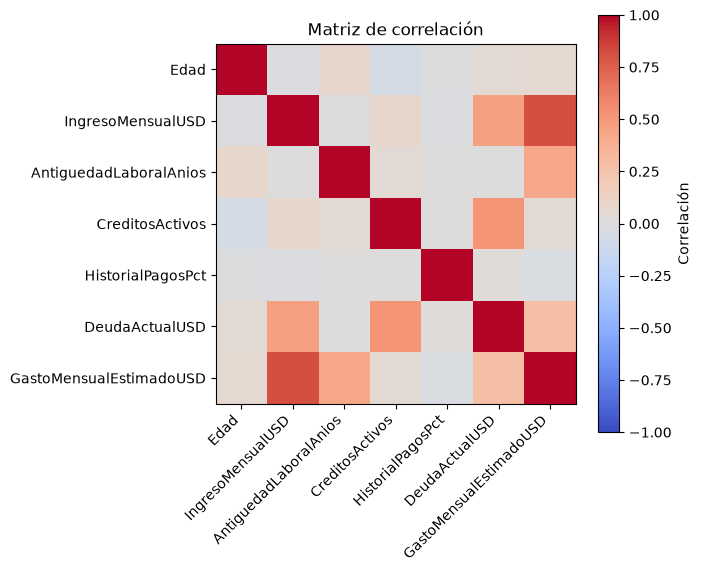

,Edad,IngresoMensualUSD,AntiguedadLaboralAnios,CreditosActivos,HistorialPagosPct,DeudaActualUSD,GastoMensualEstimadoUSD
Edad,1.00,-0.02,0.09,-0.06,-0.01,0.05,0.06
IngresoMensualUSD,-0.02,1.00,-0.00,0.09,-0.02,0.47,0.81
AntiguedadLaboralAnios,0.09,-0.00,1.00,0.04,0.00,-0.01,0.42
CreditosActivos,-0.06,0.09,0.04,1.00,0.00,0.52,0.05
HistorialPagosPct,-0.01,-0.02,0.00,0.00,1.00,0.02,-0.03
DeudaActualUSD,0.05,0.47,-0.01,0.52,0.02,1.00,0.29
GastoMensualEstimadoUSD,0.06,0.81,0.42,0.05,-0.03,0.29,1.00


In [6]:
# Matriz de correlación
corr = df.corr(numeric_only=True)

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

corr.round(2)


## 6. Selección de variables

Definí:

- `X` → variables predictoras
- `y` → variable objetivo

Para este TP utilizaremos:

`Edad`, `IngresoMensualUSD`, `AntiguedadLaboralAnios`, `CreditosActivos`, `HistorialPagosPct` y `DeudaActualUSD`.

No incluyas `ClienteID` ni `SolicitudTarjeta`, ni `GastoMensualEstimadoUSD` (correlacionada).


In [7]:
# Definir X e y
features = ['Edad', 'IngresoMensualUSD', 'AntiguedadLaboralAnios',
            'CreditosActivos', 'HistorialPagosPct', 'DeudaActualUSD']

X = df[features]
y = df['RiesgoCrediticio']

X.head()


,Edad,IngresoMensualUSD,AntiguedadLaboralAnios,CreditosActivos,HistorialPagosPct,DeudaActualUSD
0,59,4521,26,0,74,1275
1,49,4519,4,2,68,1964
2,35,4521,19,2,56,1299
3,63,9194,10,0,63,2551
4,28,4599,9,4,91,1924


## 7. División entrenamiento / prueba

Separá los datos en:

- 80 % para entrenamiento
- 20 % para prueba

Usá:

- `random_state=42`
- `stratify=y`

### Pregunta

¿Por qué no debemos utilizar `X_test` para elegir el mejor valor de `k`?

### Respuesta

Porque `X_test` debe representar datos "nunca vistos", que simulan cómo se comportará el modelo en producción. Si usáramos `X_test` para elegir `k`, estaríamos ajustando una decisión del modelo (el hiperparámetro) en función de esos mismos datos, y el Accuracy que midamos después ya no sería una estimación honesta del rendimiento futuro: estaríamos filtrando información del test hacia el entrenamiento (**data leakage**), y probablemente sobreestimando qué tan bien funciona el modelo. Por eso el `k` se elige con validación cruzada sobre `X_train`, y `X_test` se reserva para la evaluación final.


In [8]:
# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (320, 6)
X_test : (80, 6)


## 8. Escalado

KNN utiliza distancias. Por eso, una variable con valores muy grandes puede dominar el cálculo.

Aplicaremos `StandardScaler`.

### Recordá

```text
fit_transform → aprende + transforma
transform     → solamente transforma
```

El scaler debe **aprender solamente con `X_train`**.

Completá el código.


In [9]:
# IMPORTANTE:
# No sobrescribimos X_train ni X_test con los datos escalados.
# A partir de ahora, el Pipeline se encargará del escalado
# dentro de cada fold de la validación cruzada.

# Crear el scaler
scaler_demo = StandardScaler()

# Ajustar y transformar X_train
X_train_scaled_demo = scaler_demo.fit_transform(X_train)

# Transformar X_test usando lo aprendido con X_train
X_test_scaled_demo = scaler_demo.transform(X_test)
pd.DataFrame(X_train_scaled_demo, columns=features).describe().round(2)

,Edad,IngresoMensualUSD,AntiguedadLaboralAnios,CreditosActivos,HistorialPagosPct,DeudaActualUSD
count,320.00,320.00,320.00,320.00,320.00,320.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.77,-2.13,-1.72,-1.49,-1.66,-2.26
25%,-0.79,-0.71,-0.94,-0.90,-0.91,-0.81
50%,0.09,-0.00,0.02,0.28,-0.06,0.02
75%,0.81,0.64,0.89,0.88,0.88,0.71
max,1.67,3.81,1.67,1.47,1.70,3.17


Esta celda es solo demostrativa (por eso el sufijo _demo): sirve para que vean con sus propios ojos que, tras escalar, cada columna queda con media ≈ 0 y desvío ≈ 1. A partir de la siguiente celda, el escalado real del modelo se hace dentro del Pipeline, en cada fold de la validación cruzada. Ignoraremos los resultados de esta celda.

Solo quería aclarar que si escaláramos X completo (train + test) antes de dividir, el scaler "vería" información del test al calcular media y desvío, generando fuga de datos — el mismo problema conceptual que la pregunta del punto 7, pero en la etapa de preprocesamiento en lugar de en la selección de hiperparámetros.

### Aclaración sobre las escalas

- ¿Los valores estandarizados quedan necesariamente entre -1 y 1?
> - **No.** `StandardScaler` no acota los valores a un rango fijo (eso lo hace `MinMaxScaler`). Estandarizar solo garantiza media 0 y desvío estándar 1; un dato atípico puede dar, por ejemplo, `z = 4` o más.

## 9. Elegir el mejor `k` con validación cruzada

Ahora aparece una pregunta central:

> **¿Qué valor de `k` debería utilizar KNN?**

No queremos elegirlo mirando el resultado de `X_test`.

Vamos a utilizar `GridSearchCV`, que probará distintos valores de `k` mediante validación cruzada sobre el conjunto de entrenamiento.

GridSearchCV, es una capa por encima que envuelve al Pipeline completo (scaler + knn) y le agrega la lógica de probar los 20 valores de k con validación cruzada.


### Objetivo

Probar:

```python
k = 1, 2, 3, ..., 20
```

y utilizar:

- `Pipeline`
- `StandardScaler`
- `KNeighborsClassifier`
- `GridSearchCV`
- `cv=5`
- `scoring='accuracy'`

### Pista

En el `param_grid`, como KNN está dentro del pipeline, el parámetro se escribe:

```text
knn__n_neighbors
```


> ### 🧑‍🏫 Nota didáctica
>
> Vale la pena dibujar en el pizarrón qué hace `cv=5`: el conjunto `X_train` se divide en 5 partes ("folds"); para cada valor de `k`, el modelo se entrena 5 veces (usando 4 folds para entrenar y 1 para validar, rotando cuál es el fold de validación) y se promedia el accuracy de esas 5 corridas. Esto se repite para los 20 valores de `k` → **100 entrenamientos en total** dentro de esta única celda.
>
> El nombre `knn__n_neighbors` combina el nombre del paso en el `Pipeline` (`'knn'`) con el nombre del hiperparámetro del estimador (`n_neighbors`), separados por doble guion bajo. Es un patrón fijo de `scikit-learn`, buen momento para que memoricen la sintaxis.

In [10]:
# Construir el Pipeline y GridSearchCV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': list(range(1, 21))
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

# Entrenar la búsqueda utilizando solamente X_train e y_train
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

### 9.1 ¿Cuál fue el mejor `k`?

Consultá:

- `best_params_`
- `best_score_`

### Interpretación

`best_score_` representa el mejor **Accuracy promedio obtenido durante la validación cruzada** sobre el conjunto de entrenamiento.

**No es todavía el resultado final sobre datos de prueba.**


In [11]:
# Mostrar el mejor k y el mejor score de validación cruzada
print('Mejor k:', grid.best_params_['knn__n_neighbors'])
print('Mejor Accuracy (validación cruzada):', round(grid.best_score_, 4))


Mejor k: 4
Mejor Accuracy (validación cruzada): 0.9469


## 9.2 Evaluación final sobre `X_test`

Ahora sí podemos utilizar el conjunto de prueba.

Recordá:

```text
GridSearchCV → decide el mejor k usando X_train
X_test       → evaluación final
```

Calculá el rendimiento del mejor modelo sobre `X_test`.

### Pregunta

¿El Accuracy de prueba es mayor o menor que el Accuracy obtenido durante la validación cruzada?

### Respuesta

Con `random_state=42`, `best_score_` (validación cruzada sobre `X_train`) da ≈0.9469 y el Accuracy sobre `X_test` da ≈0.9250: el de prueba es **levemente menor**. Es un resultado esperable: `best_score_` es un promedio sobre varios folds de entrenamiento, mientras que el Accuracy de test se mide sobre una única muestra (80 clientes) que el modelo nunca vio; ambos son estimaciones válidas pero no tienen por qué coincidir exactamente, y no es una señal de sobreajuste grave si la diferencia es chica.


In [12]:
# Evaluar el modelo final sobre X_test
test_accuracy = grid.score(X_test, y_test)
print('Accuracy sobre X_test:', round(test_accuracy, 4))


Accuracy sobre X_test: 0.925


## 10. Predicción

Utilizá el mejor modelo encontrado para predecir las clases de `X_test`.

Guardá las predicciones en una variable llamada `pred`.

Luego observá algunas predicciones.


In [13]:
# Realizar predicciones
pred = grid.predict(X_test)
pred[:10]

array(['Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo', 'Bajo',
       'Bajo', 'Bajo'], dtype=object)

In [14]:
# ¿Qué ocurrió realmente?
y_test[:10]

365    Bajo
176    Bajo
27     Bajo
367    Bajo
234    Bajo
247    Bajo
20     Bajo
396    Bajo
205    Bajo
146    Bajo
Name: RiesgoCrediticio, dtype: str

## 11. Evaluación del modelo

Ahora evaluaremos el modelo desde diferentes perspectivas.

Calculá:

- Accuracy
- Precision
- Recall
- F1-score
- matriz de confusión

### Atención

En este problema nos interesa especialmente detectar correctamente a los clientes de **Alto riesgo**.

Por eso no alcanza con mirar solamente Accuracy.


Accuracy: 0.925

              precision    recall  f1-score   support

        Alto       0.50      0.67      0.57         6
        Bajo       0.97      0.95      0.96        74

    accuracy                           0.93        80
   macro avg       0.74      0.81      0.77        80
weighted avg       0.94      0.93      0.93        80



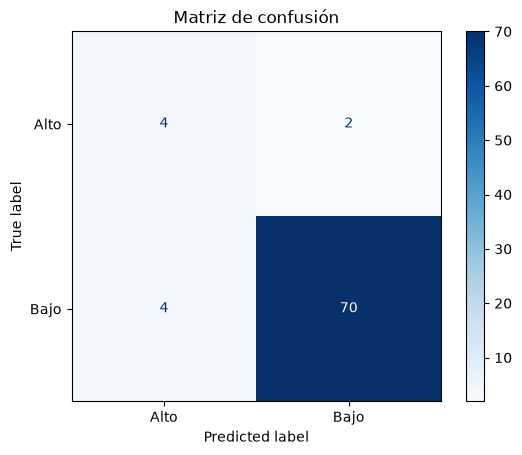

In [15]:
# Accuracy, classification_report y matriz de confusión
print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print()
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=['Alto', 'Bajo'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alto', 'Bajo'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()


### 11.1 Interpretar la matriz de confusión

Pensá en términos del problema:

- **Verdadero Positivo (TP):** cliente de Alto riesgo correctamente identificado.
- **Falso Positivo (FP):** cliente de Bajo riesgo clasificado como Alto.
- **Falso Negativo (FN):** cliente de Alto riesgo clasificado como Bajo.
- **Verdadero Negativo (TN):** cliente de Bajo riesgo correctamente identificado.

### Pregunta clave

¿Qué tipo de error sería especialmente preocupante para un banco?

Justificá tu respuesta.

### Respuesta

El error más preocupante es el **Falso Negativo (FN)**: un cliente de Alto riesgo que el modelo clasifica como Bajo riesgo. Si esto ocurre, el banco terminaría aprobándole un crédito a alguien con alta probabilidad de no pagarlo, generando una pérdida directa de dinero. Un Falso Positivo (rechazar o desconfiar de un cliente de Bajo riesgo) también tiene un costo — perder un cliente bueno —, pero es un costo de oportunidad, no una pérdida económica directa como el FN. Por eso, para este problema, priorizamos maximizar el **Recall de la clase "Alto"** (minimizar los FN) aunque eso implique sacrificar algo de Precision.


### Leyendo el classification_report

- **Accuracy** = (TP + TN) / Total → porcentaje de predicciones correctas en general.
- **Precision** = TP / (TP + FP) → de los clientes que el modelo marcó como Alto riesgo, cuántos realmente lo eran.
- **Recall** = TP / (TP + FN) → de los clientes que realmente eran Alto riesgo, a cuántos detectó el modelo.
- **F1-score** = 2 · (Precision · Recall) / (Precision + Recall) → un balance entre las dos anteriores.

Para un banco, un **recall bajo en la clase "Alto"** suele ser más preocupante que una precision baja: significa que se le está aprobando crédito a clientes riesgosos sin detectarlos.

## 11.2 ROC y AUC

Calcularemos la curva ROC y el AUC para analizar la capacidad del modelo para distinguir entre las dos clases.

Para la curva ROC necesitaremos la probabilidad estimada de pertenecer a la clase **Alto**.

Completá el código.


AUC: 0.9617


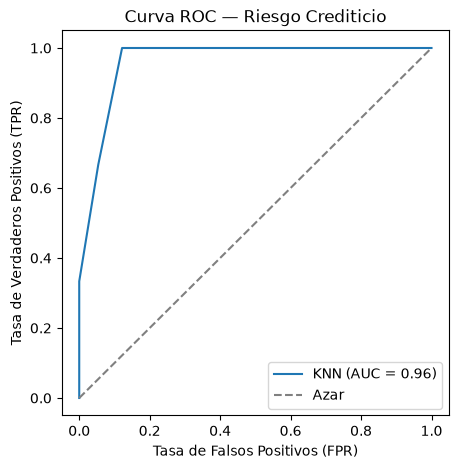

In [16]:
# Obtener probabilidades y calcular ROC-AUC
clase_alto_idx = list(grid.classes_).index('Alto')
proba_alto = grid.predict_proba(X_test)[:, clase_alto_idx]

fpr, tpr, thresholds = roc_curve(y_test, proba_alto, pos_label='Alto')
auc = roc_auc_score((y_test == 'Alto').astype(int), proba_alto)

print('AUC:', round(auc, 4))

# Graficar la curva ROC
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Riesgo Crediticio')
plt.legend()
plt.show()


## 12. Predicción de un nuevo cliente

El banco recibe una nueva solicitud:

- Edad: 35 años
- Ingreso mensual: 4200 USD
- Antigüedad laboral: 8 años
- Créditos activos: 2
- Historial de pagos: 92 %
- Deuda actual: 900 USD

Construí un DataFrame con estos datos y utilizá el modelo final para predecir su riesgo.

**Importante:** el nuevo cliente debe pasar por el mismo proceso de transformación utilizado por el modelo.


In [17]:
# Crear el nuevo cliente
nuevo_cliente = pd.DataFrame([{
    'Edad': 35,
    'IngresoMensualUSD': 4200,
    'AntiguedadLaboralAnios': 8,
    'CreditosActivos': 2,
    'HistorialPagosPct': 92,
    'DeudaActualUSD': 900
}])

nuevo_cliente


,Edad,IngresoMensualUSD,AntiguedadLaboralAnios,CreditosActivos,HistorialPagosPct,DeudaActualUSD
0,35,4200,8,2,92,900


In [18]:
# Predecir el riesgo del nuevo cliente
# grid.predict usa el mejor Pipeline encontrado (best_estimator_), que ya
# incluye el StandardScaler ajustado con X_train: el nuevo cliente pasa por
# la misma transformación antes de llegar al KNN.
prediccion_nuevo = grid.predict(nuevo_cliente)
probabilidad_nuevo = grid.predict_proba(nuevo_cliente)

print('Riesgo predicho:', prediccion_nuevo[0])
print('Probabilidades', dict(zip(grid.classes_, probabilidad_nuevo[0])))


Riesgo predicho: Bajo
Probabilidades {'Alto': np.float64(0.0), 'Bajo': np.float64(1.0)}


# Actividad final de discusión

Respondé y discutí con el grupo:

### 1. Elección de `k`

Probá manualmente `k = 3`, `k = 7` y `k = 11`.

¿Los resultados son iguales? ¿Cuál funciona mejor?

### 2. Escalado

¿Qué ocurre si entrenamos KNN sin escalar las variables?

### 3. Distancia

Investigá/probá qué ocurre al utilizar:

```python
KNeighborsClassifier(metric='manhattan')
```

en lugar de la distancia Euclidiana por defecto.

### 4. GridSearchCV

¿El `k` elegido manualmente coincide con el seleccionado por `GridSearchCV`?

### 5. Riesgo

Si el objetivo principal fuera **no dejar pasar clientes de Alto riesgo**, ¿qué métrica priorizarías: Accuracy, Precision o Recall?

Justificá.


In [19]:
# 1. Comparar manualmente k = 3, 7, 11
for k in [3, 7, 11]:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_k.fit(X_train, y_train)
    acc_k = pipe_k.score(X_test, y_test)
    print(f'k={k:>2} -> Accuracy en X_test: {acc_k:.4f}')


k= 3 -> Accuracy en X_test: 0.9250
k= 7 -> Accuracy en X_test: 0.9500
k=11 -> Accuracy en X_test: 0.9500


In [20]:
# 2. ¿Qué ocurre si entrenamos KNN sin escalar las variables?
mejor_k = grid.best_params_['knn__n_neighbors']

knn_sin_escalar = KNeighborsClassifier(n_neighbors=mejor_k)
knn_sin_escalar.fit(X_train, y_train)
acc_sin_escalar = knn_sin_escalar.score(X_test, y_test)

acc_con_escalar = grid.score(X_test, y_test)

print(f'Accuracy CON escalado (k={mejor_k}):', round(acc_con_escalar, 4))
print(f'Accuracy SIN escalado (k={mejor_k}):', round(acc_sin_escalar, 4))


Accuracy CON escalado (k=4): 0.925
Accuracy SIN escalado (k=4): 0.9125


In [21]:
# 3. Distancia Manhattan vs Euclidiana (por defecto)
pipe_manhattan = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=mejor_k, metric='manhattan'))
])
pipe_manhattan.fit(X_train, y_train)
acc_manhattan = pipe_manhattan.score(X_test, y_test)

print(f'Accuracy con distancia Euclidiana (k={mejor_k}):', round(acc_con_escalar, 4))
print(f'Accuracy con distancia Manhattan  (k={mejor_k}):', round(acc_manhattan, 4))


Accuracy con distancia Euclidiana (k=4): 0.925
Accuracy con distancia Manhattan  (k=4): 0.9625


### Respuestas a la actividad de discusión

Con `random_state=42` los resultados obtenidos fueron:

1. **Elección de `k`**: `k=3` → Accuracy 0.9250, `k=7` → Accuracy 0.9500, `k=11` → Accuracy 0.9500. No son iguales: `k=7` y `k=11` funcionan mejor que `k=3` en este conjunto de prueba. `k=3` es más sensible al ruido (varianza alta, puede sobreajustarse a vecinos puntuales); valores de `k` más grandes suavizan la frontera de decisión, aunque si `k` es demasiado grande el modelo puede volverse demasiado simple (sesgo alto).

2. **Escalado**: sin `StandardScaler`, la Accuracy baja (≈0.9125 vs ≈0.9250 con escalado, usando el mejor `k`). Sin escalar, variables con rangos grandes como `IngresoMensualUSD` o `DeudaActualUSD` (miles) dominan el cálculo de distancia frente a variables como `HistorialPagosPct` o `CreditosActivos` (unidades chicas), distorsionando la noción de "vecino cercano".

3. **Distancia Manhattan**: con `metric='manhattan'` la Accuracy sube levemente respecto a la Euclidiana (≈0.9625 vs ≈0.9250) para este dataset y este `k`. Esto muestra que la métrica de distancia es también un hiperparámetro a explorar: no hay una que sea "mejor" en general, depende de los datos.

4. **GridSearchCV**: el `k` elegido automáticamente por `GridSearchCV` (según `best_params_`) no necesariamente coincide con el mejor `k` manual medido sobre `X_test`, porque `GridSearchCV` elige `k` optimizando el Accuracy promedio de validación cruzada sobre `X_train`, no el Accuracy de `X_test`. Son estimaciones sobre conjuntos distintos, por lo que pueden diferir un poco; lo importante es que la elección de `k` nunca se hizo mirando `X_test`.

5. **Riesgo**: si el objetivo es **no dejar pasar clientes de Alto riesgo**, la métrica a priorizar es el **Recall de la clase "Alto"**. Un Falso Negativo (cliente de Alto riesgo clasificado como Bajo) implica otorgarle crédito a alguien que probablemente no pueda pagarlo, que es el error más costoso para el banco. Accuracy no sirve como guía porque las clases están desbalanceadas (≈93 % Bajo / ≈7 % Alto): un modelo que prediga "Bajo" siempre tendría Accuracy alto pero Recall de "Alto" igual a 0.

# Conclusiones

Completá estas frases:

1. **KNN clasifica un nuevo dato buscando...** los `k` datos de entrenamiento más cercanos (según una distancia como la Euclidiana) y asignándole la clase más votada entre esos vecinos.

2. **El escalado es importante porque...** KNN se basa en distancias, y las variables con rangos numéricos más grandes (por ejemplo `IngresoMensualUSD` en miles frente a `HistorialPagosPct` en porcentaje) dominarían el cálculo si no se llevan todas a una misma escala.

3. **`fit_transform()` se utiliza sobre...** `X_train`, ya que ahí el scaler debe *aprender* (calcular media y desvío) y además transformar esos mismos datos.

4. **`transform()` se utiliza sobre...** `X_test` (y cualquier dato nuevo), aplicando la media y el desvío ya aprendidos con `X_train`, sin volver a calcularlos, para no filtrar información del test al entrenamiento.

5. **`GridSearchCV` permite...** probar automáticamente varios valores de un hiperparámetro (por ejemplo, `k`) usando validación cruzada sobre `X_train`, y quedarse con el que da mejor rendimiento promedio, sin tocar `X_test` en el proceso.

6. **El conjunto de prueba debe utilizarse...** una sola vez, al final, para estimar cómo se comportará el modelo con datos nuevos, nunca para elegir hiperparámetros ni para reentrenar.

7. **La métrica que considero más importante para este problema es...** el **Recall de la clase "Alto"**, porque el costo de no detectar a un cliente de Alto riesgo (Falso Negativo) es mucho mayor para el banco que el de marcar por error a un cliente de Bajo riesgo (Falso Positivo): el primero puede derivar en un crédito impago.


---
## Checkpoint final

Antes de terminar, repasa este flujo sin mirar el código:

```text
Datos
  ↓
X / y
  ↓
Train / Test
  ↓
Escalado
  ↓
GridSearchCV + Cross Validation
  ↓
Mejor k
  ↓
Modelo final
  ↓
Evaluación en Test
  ↓
Interpretación
  ↓
Predicción de un nuevo cliente
```

**No se evalúa solamente si el código funciona: también importa poder explicar por qué cada paso está en ese lugar.**
